In [16]:
import pandas as pd
import seaborn as sns

In [17]:
def check_missing_values(name, df):
    print("Missing values in :", name)
    print("Shape of", name, df.shape)
    print()
    print("Null values in", name)
    print(df.isnull().sum())
    print()
    print("NaN values in", name)
    print(df.isna().sum())

def check_df_info(name, df):
    print("DataFrame Info for :", name)
    print("Df shape:", df.shape)
    print(df.head())
    print()
    print(df.info())
    print(df.columns)

In [18]:
credit_record = pd.read_csv('../data/Credit Risk/credit_record.csv')
application_record = pd.read_csv('../data/Credit Risk/application_record.csv')

check_df_info("credit_record", credit_record)
check_missing_values("credit_record", credit_record)

check_df_info("application_record", application_record)
check_missing_values("application_record", application_record)

DataFrame Info for : credit_record
Df shape: (1048575, 3)
        ID  MONTHS_BALANCE STATUS
0  5001711               0      X
1  5001711              -1      0
2  5001711              -2      0
3  5001711              -3      0
4  5001712               0      C

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype
---  ------          --------------    -----
 0   ID              1048575 non-null  int64
 1   MONTHS_BALANCE  1048575 non-null  int64
 2   STATUS          1048575 non-null  str  
dtypes: int64(2), str(1)
memory usage: 24.0 MB
None
Index(['ID', 'MONTHS_BALANCE', 'STATUS'], dtype='str')
Missing values in : credit_record
Shape of credit_record (1048575, 3)

Null values in credit_record
ID                0
MONTHS_BALANCE    0
STATUS            0
dtype: int64

NaN values in credit_record
ID                0
MONTHS_BALANCE    0
STATUS            0
dtype: int64
DataFrame Info for : applicat

In [19]:
# Mentioned : There're two tables could be merged by ID
# So merging them

total_data = pd.merge(application_record, credit_record, on='ID', how='inner')
data_shape = total_data.shape

print(credit_record.shape)
print(application_record.shape)
print(total_data.shape)
total_data.head()
check_missing_values("total_data", total_data)

(1048575, 3)
(438557, 18)
(777715, 20)
Missing values in : total_data
Shape of total_data (777715, 20)

Null values in total_data
ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
DAYS_BIRTH                  0
DAYS_EMPLOYED               0
FLAG_MOBIL                  0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
OCCUPATION_TYPE        240048
CNT_FAM_MEMBERS             0
MONTHS_BALANCE              0
STATUS                      0
dtype: int64

NaN values in total_data
ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE  

In [20]:
# the shape numbers are not adding up... 
print(credit_record.shape, application_record.shape, total_data.shape)
print(len(credit_record['ID'].unique()), len(application_record['ID'].unique()))
print(len(credit_record['ID']))

print(credit_record['ID'].value_counts())

# inspect duplicates
print('unique IDs:', application_record['ID'].nunique(), credit_record['ID'].nunique())
print('dup IDs in application:', (application_record['ID'].duplicated().sum()))
print('dup IDs in credit:', (credit_record['ID'].duplicated().sum()))

# Just realized credit_record is a different table which actually represents users credit history. In future we might take this into account because this is a very important feature. Will need to make a different table based on this data and use it as a feature.

(1048575, 3) (438557, 18) (777715, 20)
45985 438510
1048575
ID
5001730    61
5002160    61
5002165    61
5002171    61
5002283    61
           ..
5149672     1
5149722     1
5149854     1
5150237     1
5150334     1
Name: count, Length: 45985, dtype: int64
unique IDs: 438510 45985
dup IDs in application: 47
dup IDs in credit: 1002590


In [21]:
# Recalculating the merge 
unique_credit_records = credit_record.drop_duplicates(subset='ID', keep='first')
unique_application_records = application_record.drop_duplicates(subset='ID', keep='first')

print("Actual :", credit_record.shape, "Unique :", unique_credit_records.shape)
print("Actual :", application_record.shape, "Unique :", unique_application_records.shape)

print("IDs coexist :", application_record[application_record['ID'].isin(credit_record['ID'])].shape[0])

total_data = pd.merge(unique_application_records, unique_credit_records, on='ID', how='inner')
data_shape = total_data.shape

print(total_data.shape)
total_data.head()
check_missing_values("total_data", total_data)

Actual : (1048575, 3) Unique : (45985, 3)
Actual : (438557, 18) Unique : (438510, 18)
IDs coexist : 36457
(36457, 20)
Missing values in : total_data
Shape of total_data (36457, 20)

Null values in total_data
ID                         0
CODE_GENDER                0
FLAG_OWN_CAR               0
FLAG_OWN_REALTY            0
CNT_CHILDREN               0
AMT_INCOME_TOTAL           0
NAME_INCOME_TYPE           0
NAME_EDUCATION_TYPE        0
NAME_FAMILY_STATUS         0
NAME_HOUSING_TYPE          0
DAYS_BIRTH                 0
DAYS_EMPLOYED              0
FLAG_MOBIL                 0
FLAG_WORK_PHONE            0
FLAG_PHONE                 0
FLAG_EMAIL                 0
OCCUPATION_TYPE        11323
CNT_FAM_MEMBERS            0
MONTHS_BALANCE             0
STATUS                     0
dtype: int64

NaN values in total_data
ID                         0
CODE_GENDER                0
FLAG_OWN_CAR               0
FLAG_OWN_REALTY            0
CNT_CHILDREN               0
AMT_INCOME_TOTAL           0

In [22]:
# I think Occupation type is a categorical variable and its important. I will rank the professions based on basic sense of their payscale and them as feature later.
occupation_col = total_data['OCCUPATION_TYPE']
print(occupation_col.value_counts(dropna=False))

OCCUPATION_TYPE
NaN                      11323
Laborers                  6211
Core staff                3591
Sales staff               3485
Managers                  3012
Drivers                   2138
High skill tech staff     1383
Accountants               1241
Medicine staff            1207
Cooking staff              655
Security staff             592
Cleaning staff             551
Private service staff      344
Low-skill Laborers         175
Waiters/barmen staff       174
Secretaries                151
HR staff                    85
Realty agents               79
IT staff                    60
Name: count, dtype: int64


In [23]:
total_data.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,MONTHS_BALANCE,STATUS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0,C
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0,C
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,0,C
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,-22,X


In [24]:
total_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   36457 non-null  int64  
 1   CODE_GENDER          36457 non-null  str    
 2   FLAG_OWN_CAR         36457 non-null  str    
 3   FLAG_OWN_REALTY      36457 non-null  str    
 4   CNT_CHILDREN         36457 non-null  int64  
 5   AMT_INCOME_TOTAL     36457 non-null  float64
 6   NAME_INCOME_TYPE     36457 non-null  str    
 7   NAME_EDUCATION_TYPE  36457 non-null  str    
 8   NAME_FAMILY_STATUS   36457 non-null  str    
 9   NAME_HOUSING_TYPE    36457 non-null  str    
 10  DAYS_BIRTH           36457 non-null  int64  
 11  DAYS_EMPLOYED        36457 non-null  int64  
 12  FLAG_MOBIL           36457 non-null  int64  
 13  FLAG_WORK_PHONE      36457 non-null  int64  
 14  FLAG_PHONE           36457 non-null  int64  
 15  FLAG_EMAIL           36457 non-null  int64  
 1

In [25]:
catagorical_cols = [col for col in total_data.columns if total_data[col].dtype == 'str']
numeric_cols = [col for col in total_data.columns if total_data[col].dtype != 'str']
print("Categorical columns:", catagorical_cols)
print("Numeric columns:", numeric_cols)

Categorical columns: ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'STATUS']
Numeric columns: ['ID', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'MONTHS_BALANCE']


In [26]:
total_data['MONTHS_BALANCE'].value_counts(dropna=False)
total_data['STATUS'].value_counts(dropna=False)

# Custom status to score mapping
status_mapping = {
    'C': 2,
    'X': 1,
    '0': -1,
    '1': -2,
    '2': -3,
    '3': -4,
    '4': -5,
    '5': -6
}

# Map status to score
credit_record['STATUS_SCORE'] = credit_record['STATUS'].map(status_mapping)

# Group by ID and sum the scores
credit_record_with_score = credit_record.groupby('ID').agg({
    'STATUS_SCORE': 'sum'
}).reset_index()

print(credit_record_with_score.head(10))
print(credit_record_with_score.shape)

print("Positive Score Holders :", credit_record_with_score[credit_record_with_score['STATUS_SCORE'] < 0].shape[0])
print("Negative Score Holders :", credit_record_with_score[credit_record_with_score['STATUS_SCORE'] >= 0].shape[0])
credit_record_with_score['ID'].nunique()

# Final table with credit risk label
credit_record_with_score['CREDIT_RISK'] = (credit_record_with_score['STATUS_SCORE'] < 0).astype(int)
credit_record_with_score['CREDIT_RISK'].value_counts()

        ID  STATUS_SCORE
0  5001711            -2
1  5001712             8
2  5001713            22
3  5001714            15
4  5001715            60
5  5001717            -7
6  5001718           -12
7  5001719            80
8  5001720           -43
9  5001723            15
(45985, 2)
Positive Score Holders : 17650
Negative Score Holders : 28335


CREDIT_RISK
0    28335
1    17650
Name: count, dtype: int64

In [27]:
# Final cleanups

labeled_total_data = pd.merge(unique_application_records, credit_record_with_score[['ID', 'CREDIT_RISK']], on='ID', how='inner')
print(labeled_total_data.shape)
labeled_total_data.head()

# For now just considering numeric data
labeled_total_data_numeric = labeled_total_data.select_dtypes(include=['int64', 'float64'])
labeled_total_data_numeric.head()

# Removing negatives to maintain a positive trend and converting days to years
labeled_total_data_numeric['DAYS_BIRTH'] = labeled_total_data_numeric['DAYS_BIRTH'].abs() / 365
labeled_total_data_numeric['DAYS_EMPLOYED'] = labeled_total_data_numeric['DAYS_EMPLOYED'].abs() / 365

labeled_total_data_numeric.head()

(36457, 19)


,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,CREDIT_RISK
0,5008804,0,427500.0,32.890411,12.443836,1,1,0,0,2.0,0
1,5008805,0,427500.0,32.890411,12.443836,1,1,0,0,2.0,0
2,5008806,0,112500.0,58.832877,3.106849,1,0,0,0,2.0,0
3,5008808,0,270000.0,52.356164,8.358904,1,0,1,1,1.0,0
4,5008809,0,270000.0,52.356164,8.358904,1,0,1,1,1.0,0


<Axes: >

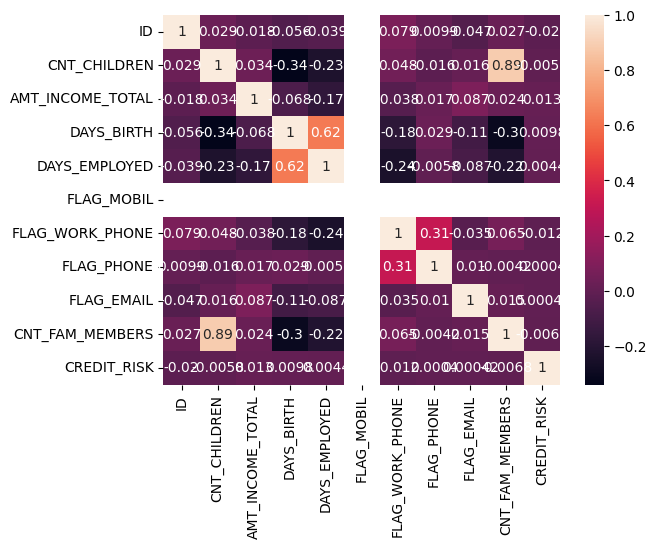

In [28]:
sns.heatmap(labeled_total_data_numeric.corr(), annot=True)

In [29]:
# sns.pairplot(labeled_total_data_numeric, hue='CREDIT_RISK')

# saving the numeric data for future use
labeled_total_data_numeric.to_csv('../data/Credit Risk/labeled_total_data_numeric.csv', index=False)